In [2]:
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [3]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [4]:
def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list

============== 1/16 ==============
epoch:0 | 0.094 - 0.098
epoch:1 | 0.097 - 0.104
epoch:2 | 0.097 - 0.155
epoch:3 | 0.097 - 0.197
epoch:4 | 0.097 - 0.219
epoch:5 | 0.097 - 0.246


/Volumes/media2/SourceCode/TIL/DeepLearning/DeepLearningFromScratchVol1/common/multi_layer_net_extend.py:109: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)
/Volumes/media2/SourceCode/TIL/DeepLearning/DeepLearningFromScratchVol1/common/multi_layer_net_extend.py:109: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)
/Volumes/media2/SourceCode/TIL/DeepLearning/DeepLearningFromScratchVol1/common/functions.py:4: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=-1, keepdims=True)


epoch:6 | 0.097 - 0.261
epoch:7 | 0.097 - 0.283
epoch:8 | 0.097 - 0.297
epoch:9 | 0.097 - 0.319
epoch:10 | 0.097 - 0.325
epoch:11 | 0.097 - 0.349
epoch:12 | 0.097 - 0.368
epoch:13 | 0.097 - 0.375
epoch:14 | 0.097 - 0.396
epoch:15 | 0.097 - 0.404
epoch:16 | 0.097 - 0.42
epoch:17 | 0.097 - 0.429
epoch:18 | 0.097 - 0.444
epoch:19 | 0.097 - 0.453
============== 2/16 ==============
epoch:0 | 0.097 - 0.118
epoch:1 | 0.097 - 0.115
epoch:2 | 0.097 - 0.163
epoch:3 | 0.097 - 0.192
epoch:4 | 0.097 - 0.208
epoch:5 | 0.097 - 0.228
epoch:6 | 0.097 - 0.248
epoch:7 | 0.097 - 0.26
epoch:8 | 0.097 - 0.279
epoch:9 | 0.097 - 0.298
epoch:10 | 0.097 - 0.307
epoch:11 | 0.097 - 0.327
epoch:12 | 0.097 - 0.341
epoch:13 | 0.097 - 0.378
epoch:14 | 0.097 - 0.394
epoch:15 | 0.097 - 0.415
epoch:16 | 0.097 - 0.428
epoch:17 | 0.097 - 0.445
epoch:18 | 0.097 - 0.454
epoch:19 | 0.097 - 0.474
============== 3/16 ==============
epoch:0 | 0.136 - 0.118
epoch:1 | 0.441 - 0.116
epoch:2 | 0.542 - 0.156
epoch:3 | 0.648 - 0.199


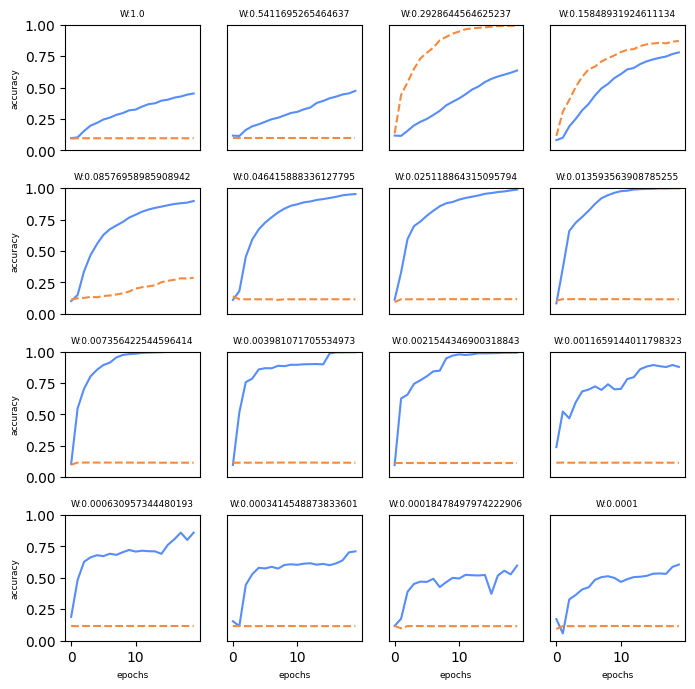

In [5]:
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(8, 8))

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w), fontsize=6.5)
    plt.plot(x, bn_train_acc_list, markevery=2)
    plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy", fontsize=6.5)
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs", fontsize=6.5)

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()